# Base de propensão a compra de carros aplicando XGboost

In [18]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Carregar a base de dados e verifique os tipos de dados, dados faltantes e dropar a coluna ID.


In [19]:
base_car = pd.read_csv("/content/sample_data/CARRO_CLIENTES.csv")

print("Dimensão inicial da base:")
display(base_car.shape)

display(base_car.head())

Dimensão inicial da base:


(1000, 5)

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [20]:
#  Inspecionar  dados
print(">> Primeiras 5 linhas:")
print(base_car.head(), "\n")

print(">> Info geral do DataFrame:")
base_car.info()
print()

>> Primeiras 5 linhas:
   User ID Gender  Age  AnnualSalary  Purchased
0      385   Male   35         20000          0
1      681   Male   40         43500          0
2      353   Male   49         74000          0
3      895   Male   40        107500          1
4      661   Male   25         79000          0 

>> Info geral do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB



In [21]:
# estatisticas descritivas
print(">> Estatísticas descritivas (numéricas):")
print(base_car.describe(), "\n")

print(">> Estatísticas descritivas (tudo):")
print(base_car.describe(include='all'), "\n")


>> Estatísticas descritivas (numéricas):
           User ID          Age   AnnualSalary    Purchased
count  1000.000000  1000.000000    1000.000000  1000.000000
mean    500.500000    40.106000   72689.000000     0.402000
std     288.819436    10.707073   34488.341867     0.490547
min       1.000000    18.000000   15000.000000     0.000000
25%     250.750000    32.000000   46375.000000     0.000000
50%     500.500000    40.000000   72000.000000     0.000000
75%     750.250000    48.000000   90000.000000     1.000000
max    1000.000000    63.000000  152500.000000     1.000000 

>> Estatísticas descritivas (tudo):
            User ID  Gender          Age   AnnualSalary    Purchased
count   1000.000000    1000  1000.000000    1000.000000  1000.000000
unique          NaN       2          NaN            NaN          NaN
top             NaN  Female          NaN            NaN          NaN
freq            NaN     516          NaN            NaN          NaN
mean     500.500000     NaN    40.10

In [22]:
#  Checagem de valores ausentes
na_counts = base_car.isnull().sum()
na_pct = (na_counts / len(base_car) * 100).round(2)
ausente_car = pd.DataFrame({
    'contagem_ausentes': na_counts,
    'porcentagem_ausentes': na_pct
})
print(">> Valores ausentes por coluna:")
print(ausente_car, "\n")

>> Valores ausentes por coluna:
              contagem_ausentes  porcentagem_ausentes
User ID                       0                   0.0
Gender                        0                   0.0
Age                           0                   0.0
AnnualSalary                  0                   0.0
Purchased                     0                   0.0 



In [23]:
# verificação de valores únicos para confirmar que não tem nenhum residuo

print(">> Valores únicos na coluna 'Gender':")
print(base_car['Gender'].unique())
print("\n")

>> Valores únicos na coluna 'Gender':
['Male' 'Female']




In [24]:
base_car = base_car.drop('User ID', axis=1)

print("Dimensão da base após remover a coluna 'User ID':")
display(base_car.shape)

display(base_car.head())

Dimensão da base após remover a coluna 'User ID':


(1000, 4)

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


# Aplicar o Label Encoder para a coluna Gender e excluir a coluna categórica.


In [25]:
# Identificar todas as colunas categóricas (tipo 'object')
categorical_columns = base_car.select_dtypes(include='object').columns.tolist()

print("Colunas categóricas no DataFrame:")
for col in categorical_columns:
    print(f"- {col}")

Colunas categóricas no DataFrame:
- Gender


In [26]:
le = LabelEncoder()
base_car['Gender'] = le.fit_transform(base_car['Gender'])

print("Valores únicos na coluna 'Gender' após Label Encoding:")
print(base_car['Gender'].unique())

display(base_car.head())

Valores únicos na coluna 'Gender' após Label Encoding:
[1 0]


,Gender,Age,AnnualSalary,Purchased
0,1,35,20000,0
1,1,40,43500,0
2,1,49,74000,0
3,1,40,107500,1
4,1,25,79000,0


# Fazer a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

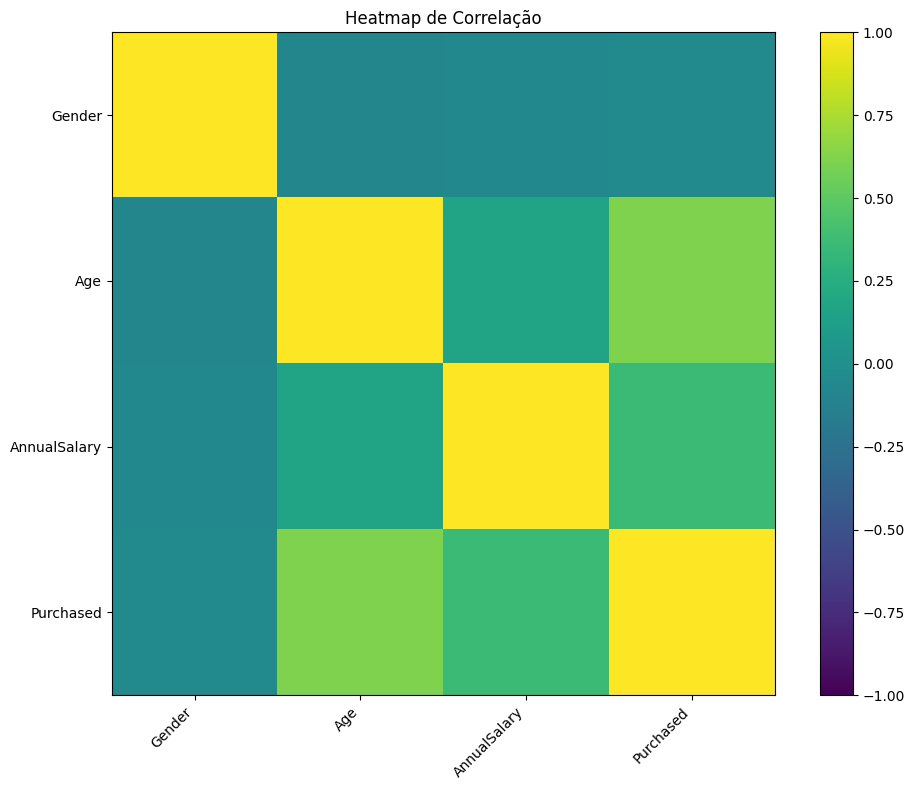

In [27]:
# Heatmap de correlacao
num_cols = ['Gender', 'Age', 'AnnualSalary', 'Purchased']
corr = base_car[num_cols].corr()
plt.figure(figsize=(12,8))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('Heatmap de Correlação')
plt.tight_layout()
plt.show()

In [28]:
print("Correlação com a variável target 'Purchased':")
print(corr['Purchased'].sort_values(ascending=False))

print("\nAnálise:")
print("A variável 'Age' possui a maior correlação positiva com 'Purchased' (0.616).")
print("Em seguida, 'AnnualSalary' também mostra uma correlação positiva significativa (0.365).")
print("A variável 'Gender' apresenta uma correlação muito baixa e negativa (-0.047), indicando pouca influência direta no 'Purchased' no que tange a correlação linear.")

Correlação com a variável target 'Purchased':
Purchased       1.000000
Age             0.616036
AnnualSalary    0.364974
Gender         -0.047211
Name: Purchased, dtype: float64

Análise:
A variável 'Age' possui a maior correlação positiva com 'Purchased' (0.616).
Em seguida, 'AnnualSalary' também mostra uma correlação positiva significativa (0.365).
A variável 'Gender' apresenta uma correlação muito baixa e negativa (-0.047), indicando pouca influência direta no 'Purchased' no que tange a correlação linear.


# Fazer a separação da base em X e Y e em seguida nas bases de treino e teste.

In [29]:
X = base_car.drop('Purchased', axis=1)
Y = base_car['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Dimensão de X_train:", X_train.shape)
print("Dimensão de X_test:", X_test.shape)
print("Dimensão de y_train:", y_train.shape)
print("Dimensão de y_test:", y_test.shape)

Dimensão de X_train: (800, 3)
Dimensão de X_test: (200, 3)
Dimensão de y_train: (800,)
Dimensão de y_test: (200,)


# Treinar o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [30]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

print("Modelo XGBoost treinado com sucesso!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:20:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo XGBoost treinado com sucesso!


# Realizar as previsões para a base de teste, trazendo as probabilidades das previsões.

In [33]:
Y_pred = model.predict(X_test)           # Previsões das classes
Y_pred_prob = model.predict_proba(X_test)  # Probabilidades de cada classe

In [34]:
Y_pred_prob

array([[8.30259621e-01, 1.69740364e-01],
       [1.03157640e-01, 8.96842360e-01],
       [9.99044836e-01, 9.55166644e-04],
       [8.31745684e-01, 1.68254316e-01],
       [3.10941696e-01, 6.89058304e-01],
       [4.11250591e-02, 9.58874941e-01],
       [3.12089920e-03, 9.96879101e-01],
       [9.98471856e-01, 1.52817171e-03],
       [9.90240812e-01, 9.75916348e-03],
       [9.95115757e-01, 4.88425605e-03],
       [9.33773100e-01, 6.62268847e-02],
       [9.99028087e-01, 9.71894653e-04],
       [8.31634879e-01, 1.68365121e-01],
       [9.98144150e-01, 1.85585290e-03],
       [1.10270381e-02, 9.88972962e-01],
       [8.32515955e-02, 9.16748405e-01],
       [5.06335497e-01, 4.93664503e-01],
       [1.43213272e-01, 8.56786728e-01],
       [5.03790975e-02, 9.49620903e-01],
       [9.98564363e-01, 1.43564970e-03],
       [9.97784734e-01, 2.21528183e-03],
       [5.43743372e-03, 9.94562566e-01],
       [1.89163089e-02, 9.81083691e-01],
       [9.99029636e-01, 9.70339286e-04],
       [2.132570

# Fazer a transformação das probabilidades nas previsões binárias e avaliar o desempenho do modelo.

In [37]:
# Então uma vez que temos as probabilidades, fazemos a transformação das previsões e os rótulos de volta para os rótulos originais
Y_pred_original = le.inverse_transform(Y_pred)
Y_test_original = le.inverse_transform(y_test)

In [38]:
accuracy = accuracy_score(Y_test_original, Y_pred_original)
report = classification_report(Y_test_original, Y_pred_original)
conf_matrix = confusion_matrix(Y_test_original, Y_pred_original)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.91
Relatório de Classificação:
              precision    recall  f1-score   support

      Female       0.90      0.95      0.92       112
        Male       0.93      0.86      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

Matriz de Confusão:
[[106   6]
 [ 12  76]]


# Trazer a lista com a feature importance.

In [40]:
importances = model.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

        Feature  Importance
1           Age    4.565184
2  AnnualSalary    2.471006
0        Gender    0.741034


In [44]:
print('Correlação com a variável target \'Purchased\':')
print(corr['Purchased'].sort_values(ascending=False))

print('\nImportância das Features (XGBoost):')
print(importance_df)

Correlação com a variável target 'Purchased':
Purchased       1.000000
Age             0.616036
AnnualSalary    0.364974
Gender         -0.047211
Name: Purchased, dtype: float64

Importância das Features (XGBoost):
        Feature  Importance
1           Age    4.565184
2  AnnualSalary    2.471006
0        Gender    0.741034


Sim, são as mesmas( Age e AnnualSalary) que apresentaram maior correlação positiva com a variável target 'Purchased' na matriz de correlação com Age sendo a mais influente em ambos os casos. Por outro lado, Gender apresentou baixa correlação e a menor importância no modelo XGBoost.